In [73]:
import math
import random
import torch
import os

# 强制让 Python 所有 requests 网络请求走本地代理
os.environ['http_proxy'] = 'http://127.0.0.1:10808'
os.environ['https_proxy'] = 'http://127.0.0.1:10808'

In [74]:
import os
import hashlib
import zipfile
import tarfile
import requests

# 1. 定义数据源
DATA_HUB = dict()
DATA_URL = 'https://d2l-data.s3-accelerate.amazonaws.com/'
DATA_HUB['ptb'] = (DATA_URL + 'ptb.zip',
                   '319d85e578af0cdc590547f26231e4e31cdf1e42')

# 2. 定义下载函数
def download(name, cache_dir=os.path.join('.', 'data'), *,
             max_attempts=5, timeout=(10, 30), retry_backoff=1.0):
    """Download with verified caching and resumable .part files; never publish bad data."""
    import re
    import time
    from urllib.parse import urlsplit

    if name not in DATA_HUB:
        raise KeyError(f'Unknown dataset: {name}')
    if max_attempts < 1 or retry_backoff < 0:
        raise ValueError('max_attempts must be positive and retry_backoff nonnegative')
    url, sha1_hash = DATA_HUB[name]
    # Also upgrade entries registered before this function was redefined.
    if url.startswith('http://d2l-data.s3-accelerate.amazonaws.com/'):
        url = 'https://' + url[len('http://'):]
    filename = os.path.basename(urlsplit(url).path)
    if not filename:
        raise ValueError(f'URL has no filename: {url}')
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, filename)
    part = fname + '.part'

    def file_sha1(path):
        if not os.path.isfile(path):
            return None
        digest = hashlib.sha1()
        with open(path, 'rb') as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b''):
                digest.update(chunk)
        return digest.hexdigest()

    if file_sha1(fname) == sha1_hash:
        return fname

    last_error = None
    for attempt in range(1, max_attempts + 1):
        # Recover a completed .part file left before the atomic rename.
        if file_sha1(part) == sha1_hash:
            os.replace(part, fname)
            return fname
        offset = os.path.getsize(part) if os.path.isfile(part) else 0
        headers = {'Accept-Encoding': 'identity'}
        if offset:
            headers['Range'] = f'bytes={offset}-'
        print(f'Downloading {filename}: attempt {attempt}/{max_attempts}, '
              f'resuming at {offset} bytes')
        try:
            with requests.get(url, headers=headers, stream=True,
                              timeout=timeout, verify=True) as response:
                # A stale/oversized partial file cannot be resumed. Start afresh.
                if response.status_code == 416 and offset:
                    os.remove(part)
                    last_error = RuntimeError('Server rejected the saved byte range')
                    continue
                response.raise_for_status()
                if response.headers.get('Content-Encoding', 'identity').lower() != 'identity':
                    raise ValueError('Cannot safely resume an encoded HTTP response')
                content_length = response.headers.get('Content-Length')
                expected_bytes = int(content_length) if content_length is not None else None
                if expected_bytes is not None and expected_bytes < 0:
                    raise ValueError('Invalid negative Content-Length')
                if response.status_code == 206:
                    match = re.fullmatch(r'bytes (\d+)-(\d+)/(\d+)',
                                         response.headers.get('Content-Range', ''))
                    if match is None:
                        raise ValueError('Missing or malformed Content-Range')
                    start, end, total = map(int, match.groups())
                    if start != offset or not start <= end < total:
                        raise ValueError(f'Wrong Content-Range: expected start {offset}, '
                                         f'got {response.headers.get("Content-Range")}')
                    if expected_bytes is not None and expected_bytes != end - start + 1:
                        raise ValueError('Content-Length disagrees with Content-Range')
                    expected_bytes = end - start + 1
                    mode = 'ab' if offset else 'wb'
                elif response.status_code == 200:
                    # A server may ignore Range. Replace the partial body, never append it.
                    mode, offset, total = 'wb', 0, expected_bytes
                else:
                    raise ValueError(f'Unexpected download status: {response.status_code}')

                received = 0
                with open(part, mode) as f:
                    for chunk in response.iter_content(chunk_size=256 * 1024):
                        if chunk:
                            if expected_bytes is not None and received + len(chunk) > expected_bytes:
                                raise ValueError('Response body exceeds its declared byte range')
                            f.write(chunk)
                            received += len(chunk)
                    f.flush()
                    os.fsync(f.fileno())
                if expected_bytes is not None and received != expected_bytes:
                    raise requests.exceptions.ChunkedEncodingError(
                        f'Expected {expected_bytes} bytes, received {received}')
                if total is not None and os.path.getsize(part) < total:
                    last_error = RuntimeError('Server returned only part of the remaining file')
                    continue
            actual_sha1 = file_sha1(part)
            if actual_sha1 != sha1_hash:
                # A complete but corrupt body is not a trustworthy resume prefix.
                os.remove(part)
                raise ValueError(f'SHA1 mismatch for {filename}: expected {sha1_hash}, '
                                 f'got {actual_sha1}; corrupt partial discarded')
            os.replace(part, fname)
            return fname
        except requests.RequestException as exc:
            last_error = exc
            if attempt < max_attempts:
                time.sleep(min(retry_backoff * 2 ** (attempt - 1), 8))
    raise RuntimeError(f'Download failed after {max_attempts} attempts: {url}. '
                       f'Any resumable data remains at {part}') from last_error

# 3. 定义解压函数
def download_extract(name, folder=None, *, cache_dir=None):
    """Download once and extract with progress and a verified completion marker."""
    import json
    import time
    from pathlib import Path

    fname = download(name) if cache_dir is None else download(name, cache_dir)
    archive = Path(fname)
    base_dir = archive.parent
    data_dir = base_dir / folder if folder else archive.with_suffix('')
    expected_sha1 = DATA_HUB[name][1]
    marker = base_dir / (archive.name + '.extracted.json')
    if marker.is_file() and data_dir.is_dir():
        try:
            saved = json.loads(marker.read_text(encoding='utf-8'))
            if (isinstance(saved, dict) and saved.get('sha1') == expected_sha1
                    and saved.get('data_dir') == str(data_dir.resolve())):
                print(f'Using extracted {name}: {data_dir}', flush=True)
                return str(data_dir)
        except (OSError, ValueError):
            pass

    started = time.monotonic()
    print(f'Extracting {archive.name} -> {base_dir}', flush=True)

    def progress(members):
        last_update = time.monotonic()
        for count, member in enumerate(members, 1):
            yield member
            now = time.monotonic()
            if now - last_update >= 5:
                print(f'  {count:,} entries extracted ({now - started:.1f}s)', flush=True)
                last_update = now

    if archive.suffix == '.zip':
        with zipfile.ZipFile(archive, 'r') as fp:
            fp.extractall(base_dir, members=progress(fp.infolist()))
    elif archive.suffix in ('.tar', '.gz'):
        with tarfile.open(archive, 'r:*') as fp:
            fp.extractall(base_dir, members=progress(fp), filter='data')
    else:
        raise ValueError(f'Unsupported archive type: {archive.name}')

    if not data_dir.is_dir():
        raise FileNotFoundError(f'Expected extracted directory does not exist: {data_dir}')
    temporary_marker = marker.with_name(marker.name + '.tmp')
    temporary_marker.write_text(json.dumps({
        'sha1': expected_sha1, 'data_dir': str(data_dir.resolve())
    }) + '\n', encoding='utf-8')
    temporary_marker.replace(marker)
    print(f'Extracted {name} in {time.monotonic() - started:.1f}s: {data_dir}', flush=True)
    return str(data_dir)

# 4. 读取数据集
def read_ptb():
    """将PTB数据集加载到文本行的列表中"""
    data_dir = download_extract('ptb')
    with open(os.path.join(data_dir, 'ptb.train.txt')) as f:
        raw_text = f.read()
    return [line.split() for line in raw_text.split('\n')]

sentences = read_ptb()
print(f'# sentences数: {len(sentences)}')

# sentences数: 42069


In [75]:
import collections

def count_corpus(tokens):
    """统计词元的频率"""
    # 这里的 tokens 是 1D 列表或 2D 列表
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # 将词元列表展平成一个列表
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

class Vocab:
    """文本词表"""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 按出现频率排序
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        # 未知词元的索引为0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):  # 未知词元的索引为0
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

# 构建词表
vocab = Vocab(sentences, min_freq=10)
print(f'vocab size: {len(vocab)}')

vocab size: 6719


In [76]:
vocab = Vocab(sentences, min_freq=10)
f'vocab size: {len(vocab)}'

'vocab size: 6719'

In [77]:
def subsample(sentences, vocab):
    """下采样高频词"""
    # 排除未知词元'<unk>'
    sentences = [[token for token in line if vocab[token] != vocab.unk]
                 for line in sentences]
    counter = count_corpus(sentences)
    num_tokens = sum(counter.values())

    # 如果在下采样期间保留词元，则返回True
    def keep(token):
        return(random.uniform(0, 1) <
               math.sqrt(1e-4 / counter[token] * num_tokens))

    return ([[token for token in line if keep(token)] for line in sentences],
            counter)

subsampled, counter = subsample(sentences, vocab)

In [78]:
import matplotlib.pyplot as plt

def show_list_len_pair_hist(labels, xlabel, ylabel, *args):
    """绘制列表长度对的直方图"""
    plt.figure(figsize=(4.5, 3))
    # 统计各个列表中子列表的长度并绘制直方图
    _, _, patches = plt.hist(
        [[len(l) for l in p] for p in args], label=labels)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # 为两组柱状图添加不同纹理以示区分
    if len(patches) >= 2:
        plt.setp(patches[0], hatch='/')
        plt.setp(patches[1], hatch='\\')
    plt.legend()
    plt.show()

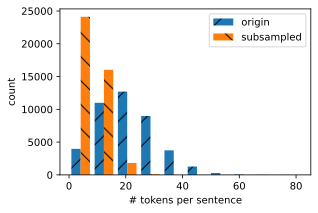

In [79]:
show_list_len_pair_hist(
    ['origin', 'subsampled'], '# tokens per sentence',
    'count', sentences, subsampled)

In [80]:
def compare_counts(token):
    return (f'"{token}"的数量：'
            f'之前={sum([l.count(token) for l in sentences])}, '
            f'之后={sum([l.count(token) for l in subsampled])}')

compare_counts('the')

'"the"的数量：之前=50770, 之后=2055'

In [81]:
compare_counts('join')

'"join"的数量：之前=45, 之后=45'

In [82]:
corpus = [vocab[line] for line in subsampled]
corpus[:3]

[[], [2115, 274], [140, 5277, 3054, 1580]]

In [83]:
def get_centers_and_contexts(corpus, max_window_size):
    """返回跳元模型中的中心词和上下文词"""
    centers, contexts = [], []
    for line in corpus:
        # 要形成“中心词-上下文词”对，每个句子至少需要有2个词
        if len(line) < 2:
            continue
        centers += line
        for i in range(len(line)):  # 上下文窗口中间i
            window_size = random.randint(1, max_window_size)
            indices = list(range(max(0, i - window_size),
                                 min(len(line), i + 1 + window_size)))
            # 从上下文词中排除中心词
            indices.remove(i)
            contexts.append([line[idx] for idx in indices])
    return centers, contexts

In [84]:
tiny_dataset = [list(range(7)), list(range(7, 10))]
print('数据集', tiny_dataset)
for center, context in zip(*get_centers_and_contexts(tiny_dataset, 2)):
    print('中心词', center, '的上下文词是', context)

数据集 [[0, 1, 2, 3, 4, 5, 6], [7, 8, 9]]
中心词 0 的上下文词是 [1, 2]
中心词 1 的上下文词是 [0, 2, 3]
中心词 2 的上下文词是 [1, 3]
中心词 3 的上下文词是 [2, 4]
中心词 4 的上下文词是 [3, 5]
中心词 5 的上下文词是 [3, 4, 6]
中心词 6 的上下文词是 [4, 5]
中心词 7 的上下文词是 [8]
中心词 8 的上下文词是 [7, 9]
中心词 9 的上下文词是 [8]


In [85]:
all_centers, all_contexts = get_centers_and_contexts(corpus, 5)
f'# “中心词-上下文词对”的数量: {sum([len(contexts) for contexts in all_contexts])}'

'# “中心词-上下文词对”的数量: 1503517'

In [86]:
class RandomGenerator:
    """根据n个采样权重在{1,...,n}中随机抽取"""
    def __init__(self, sampling_weights):
        # Exclude
        self.population = list(range(1, len(sampling_weights) + 1))
        self.sampling_weights = sampling_weights
        self.candidates = []
        self.i = 0

    def draw(self):
        if self.i == len(self.candidates):
            # 缓存k个随机采样结果
            self.candidates = random.choices(
                self.population, self.sampling_weights, k=10000)
            self.i = 0
        self.i += 1
        return self.candidates[self.i - 1]

In [87]:
generator = RandomGenerator([2, 3, 4])
[generator.draw() for _ in range(10)]

[1, 1, 3, 2, 1, 2, 3, 2, 2, 3]

In [88]:
def get_negatives(all_contexts, vocab, counter, K):
    """返回负采样中的噪声词"""
    # 索引为1、2、...（索引0是词表中排除的未知标记）
    sampling_weights = [counter[vocab.to_tokens(i)]**0.75
                        for i in range(1, len(vocab))]
    all_negatives, generator = [], RandomGenerator(sampling_weights)
    for contexts in all_contexts:
        negatives = []
        while len(negatives) < len(contexts) * K:
            neg = generator.draw()
            # 噪声词不能是上下文词
            if neg not in contexts:
                negatives.append(neg)
        all_negatives.append(negatives)
    return all_negatives

all_negatives = get_negatives(all_contexts, vocab, counter, 5)

In [89]:
def batchify(data):
    """返回带有负采样的跳元模型的小批量样本"""
    max_len = max(len(c) + len(n) for _, c, n in data)
    centers, contexts_negatives, masks, labels = [], [], [], []
    for center, context, negative in data:
        cur_len = len(context) + len(negative)
        centers += [center]
        contexts_negatives += \
            [context + negative + [0] * (max_len - cur_len)]
        masks += [[1] * cur_len + [0] * (max_len - cur_len)]
        labels += [[1] * len(context) + [0] * (max_len - len(context))]
    return (torch.tensor(centers).reshape((-1, 1)), torch.tensor(
        contexts_negatives), torch.tensor(masks), torch.tensor(labels))

In [90]:
x_1 = (1, [2, 2], [3, 3, 3, 3])
x_2 = (1, [2, 2, 2], [3, 3])
batch = batchify((x_1, x_2))

names = ['centers', 'contexts_negatives', 'masks', 'labels']
for name, data in zip(names, batch):
    print(name, '=', data)

centers = tensor([[1],
        [1]])
contexts_negatives = tensor([[2, 2, 3, 3, 3, 3],
        [2, 2, 2, 3, 3, 0]])
masks = tensor([[1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0]])
labels = tensor([[1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0]])


In [91]:
import os
import sys
import platform
import torch

def get_dataloader_workers(max_workers: int = 4) -> int:
    """
    自适应获取 DataLoader 的最佳 worker 数量（标准 d2l 零参接口规范）
    
    调用方式：
        num_workers = get_dataloader_workers()
        
    调度逻辑：
    1. 环境防御：Windows + Jupyter/IPython 下自动返回 0（防止 spawn 序列化报错导致内核崩溃）
    2. 资源感知：优先获取容器/系统可用的真实 CPU 核心数，并结合 GPU 卡数综合决策
    3. 负载自适应：自动分配合理的 worker 数，确保主进程和系统调度不卡顿
    """
    # 1. 检查操作系统与运行环境（Windows Notebook 强制 0 保障不崩溃）
    is_windows = sys.platform.startswith('win') or platform.system() == 'Windows'
    is_notebook = 'ipykernel' in sys.modules or 'IPython' in sys.modules
    if is_windows and is_notebook:
        return 0

    # 2. 获取当前环境真实可用的 CPU 核心数（兼容 Docker/K8s 容器 CPU 配额）
    try:
        cpu_count = len(os.sched_getaffinity(0))
    except (AttributeError, NotImplementedError):
        cpu_count = os.cpu_count() or 1

    # 3. 单核环境直接返回 0，无需开启多进程额外开销
    if cpu_count <= 1:
        return 0

    # 4. 结合 GPU 数量和 CPU 核心数进行调度
    num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
    if num_gpus > 0:
        # 有 GPU 时：通常每张卡分配 2~4 个 workers，且不超过 (cpu_count - 1)
        suggested = min(num_gpus * 4, cpu_count - 1)
    else:
        # 纯 CPU 训练：预留 1 核给主线程，其余用于数据加载
        suggested = cpu_count - 1

    # 5. 限制在合理上限区间 [0, max_workers]
    return max(0, min(suggested, max_workers))

In [92]:
def load_data_ptb(batch_size, max_window_size, num_noise_words):
    """下载PTB数据集，然后将其加载到内存中"""
    num_workers = get_dataloader_workers()
    sentences = read_ptb()
    vocab = Vocab(sentences, min_freq=10)
    subsampled, counter = subsample(sentences, vocab)
    corpus = [vocab[line] for line in subsampled]
    all_centers, all_contexts = get_centers_and_contexts(
        corpus, max_window_size)
    all_negatives = get_negatives(
        all_contexts, vocab, counter, num_noise_words)

    class PTBDataset(torch.utils.data.Dataset):
        def __init__(self, centers, contexts, negatives):
            assert len(centers) == len(contexts) == len(negatives)
            self.centers = centers
            self.contexts = contexts
            self.negatives = negatives

        def __getitem__(self, index):
            return (self.centers[index], self.contexts[index],
                    self.negatives[index])

        def __len__(self):
            return len(self.centers)

    dataset = PTBDataset(all_centers, all_contexts, all_negatives)

    data_iter = torch.utils.data.DataLoader(
        dataset, batch_size, shuffle=True,
        collate_fn=batchify, num_workers=num_workers)
    return data_iter, vocab

In [93]:
data_iter, vocab = load_data_ptb(512, 5, 5)
for batch in data_iter:
    for name, data in zip(names, batch):
        print(name, 'shape:', data.shape)
    break

centers shape: torch.Size([512, 1])
contexts_negatives shape: torch.Size([512, 60])
masks shape: torch.Size([512, 60])
labels shape: torch.Size([512, 60])


## 14.3.8. 练习与参考答案

### 1. 如果不使用下采样，本节中代码的运行时间会发生什么变化？
**答案：**
代码的运行时间（包括数据预处理与后续模型训练）会**显著增加（增加数倍以上）**。主要原因如下：
1. **样本对数量呈爆炸式增长**：像 'the'、'a'、'in' 这样的高频停用词在语料库中占据极大比例（例如数据集中的 'the' 在下采样前有 50,000+ 次，下采样后仅保留约 2,000 次，削减了 95% 以上）。如果不进行下采样，语料总词元数会大幅增加。
2. **中心词-上下文词对剧增**：每个未被下采样丢弃的高频词都会作为中心词生成滑动窗口上下文，且频繁出现在其他中心词的上下文中，生成的 `(center, context)` 样本对数量呈倍数剧增。
3. **负采样与批处理计算量成倍上升**：每个上下文词都需要抽取 $K$ 个负样本噪声词，总上下文增多导致 `get_negatives` 随机采样次数和 `batchify` 的填充耗时线性上升。
4. **模型训练计算严重浪费**：每个 epoch 的 batch 数量大幅增多，不仅耗费大量显存与计算时间，而且模型会在无区分度的高频停用词上浪费大量梯度更新。

---

### 2. RandomGenerator 类缓存 k 个随机采样结果。将 k 设置为其他值，看看它如何影响数据加载速度。
**答案：**
`k` 值代表每次批量抽取随机数时的缓存大小（即批量采样的批大小），它对速度的影响呈现“两头慢、中间快”的特性：
1. **当 $k$ 过小（例如 $k=1$ 或 $k=10$）时，加载速度会极其缓慢**：
   - `random.choices` 底层需要进行权重累积分布计算与初始化开销。如果每次只采样极少量结果，会产生极其频繁的 Python 函数调用与循环开销，严重拖慢负采样速度。
2. **当 $k$ 适中（例如 $k=10^4 \sim 10^5$）时，速度达到最优平衡点**：
   - 一次性批量生成足够的候选词列表，充分摊薄了单次调用的固定开销，在内存消耗极小的前提下实现了极高吞吐的常数级抽取。
3. **当 $k$ 过大（例如 $k \ge 10^8$）时，可能出现内存浪费或负优化**：
   - 占用过多系统内存，且首次初始化的单次阻塞时间变长；若实际需要的噪声词数量少于 $k$，多余的随机数生成会造成算力与内存浪费。

---

### 3. 本节代码中的哪些其他超参数可能会影响数据加载速度？
**答案：**
除了下采样和缓存大小 $k$ 外，以下超参数均会直接影响数据加载与预处理速度：
1. **`max_window_size`（最大上下文窗口大小）**：
   - 窗口越大，每个中心词关联的上下文词越多，产生的样本对总数呈线性增长，负采样量和批处理序列最大长度也相应增加，增加耗时。
2. **`num_noise_words`（$K$，每个上下文词采样的噪声词数量）**：
   - $K$ 越大，需要采样的负样本数量越多，`RandomGenerator.draw()` 调用次数成倍增长，且 `batchify` 中每个样本的序列长度（`len(context) + len(negative)`）变长，张量填充耗时增加。
3. **`min_freq`（构建词表的最小词频阈值）**：
   - `min_freq` 越小，保留的低频罕见词越多，词表更大，被过滤为 `<unk>` 的词变少，生成的总样本对数量更多，预处理时间变长。
4. **`batch_size`（批量大小）**：
   - 较小的 `batch_size` 会增加 DataLoader 的迭代次数和 Python 调度/`batchify` 函数调用开销；适度增大的 `batch_size` 能够提升批处理的并行吞吐量。
5. **下采样公式中的阈值常数（代码中硬编码为 $10^{-4}$ 的参数 $t$）**：
   - 决定高频词被丢弃的概率。$t$ 越小，丢弃的高频词越多，总语料缩减越明显，数据加载越快；反之 $t$ 越大，数据量越大，加载越慢。
6. **`num_workers`（DataLoader 进程数）**：
   - 影响 DataLoader 多进程并行批处理与异步预加载的并发吞吐能力。


In [94]:
import math
import torch
from torch import nn

batch_size, max_window_size, num_noise_words = 512, 5, 5
data_iter, vocab = load_data_ptb(batch_size, max_window_size,
                                     num_noise_words)

In [95]:
embed = nn.Embedding(num_embeddings=20, embedding_dim=4)
print(f'Parameter embedding_weight ({embed.weight.shape}, '
      f'dtype={embed.weight.dtype})')

Parameter embedding_weight (torch.Size([20, 4]), dtype=torch.float32)


In [96]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
embed(x)

tensor([[[ 2.0741, -1.0859, -0.0571, -0.1415],
         [-1.5994,  0.1213,  0.2991, -0.3279],
         [ 0.3620, -1.9180, -0.0719, -0.5367]],

        [[-0.2955, -0.9248,  1.3097,  0.7822],
         [-0.3912,  0.4380,  0.2801,  0.3556],
         [ 0.4580, -2.7348, -0.7213,  1.7709]]], grad_fn=<EmbeddingBackward0>)

In [97]:
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    v = embed_v(center)
    u = embed_u(contexts_and_negatives)
    pred = torch.bmm(v, u.permute(0, 2, 1))
    return pred

In [98]:
skip_gram(torch.ones((2, 1), dtype=torch.long),
          torch.ones((2, 4), dtype=torch.long), embed, embed).shape

torch.Size([2, 1, 4])

In [99]:
class SigmoidBCELoss(nn.Module):
    # 带掩码的二元交叉熵损失
    def __init__(self):
        super().__init__()

    def forward(self, inputs, target, mask=None):
        out = nn.functional.binary_cross_entropy_with_logits(
            inputs, target, weight=mask, reduction="none")
        return out.mean(dim=1)

loss = SigmoidBCELoss()

In [100]:
pred = torch.tensor([[1.1, -2.2, 3.3, -4.4]] * 2)
label = torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
mask = torch.tensor([[1, 1, 1, 1], [1, 1, 0, 0]])
loss(pred, label, mask) * mask.shape[1] / mask.sum(axis=1)

tensor([0.9352, 1.8462])

In [101]:
embed_size = 100
net = nn.Sequential(nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size),
                    nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size))

In [102]:
# ============================================================
# 辅助工具函数与类：GPU检测、计时器、累加器及动画绘制器
# ============================================================
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# 1. GPU 设备检测（解决 try_gpu 未定义问题）
def try_gpu(i=0):
    """如果存在，则返回gpu(i)，否则返回cpu()"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def try_all_gpus():
    """返回所有可用的GPU，如果没有GPU，则返回[cpu(),]"""
    devices = [torch.device(f'cuda:{i}')
               for i in range(torch.cuda.device_count())]
    return devices if devices else [torch.device('cpu')]

# 2. 运行计时器
class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

# 3. 多变量累加器
class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# 4. 绘图辅助函数
def use_svg_display():
    """使用svg格式在Jupyter中显示图像"""
    try:
        from matplotlib_inline import backend_inline
        backend_inline.set_matplotlib_formats('svg')
    except Exception:
        pass

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    if xlim:
        axes.set_xlim(xlim)
    if ylim:
        axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

# 5. 动画绘制器 Animator
class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        use_svg_display()
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        """向图表中添加多个数据点"""
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x_arr, y_arr, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x_arr, y_arr, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)


In [103]:
def train(net, data_iter, lr, num_epochs, device=try_gpu()):
    def init_weights(m):
        if type(m) == nn.Embedding:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    net = net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs])
    # 规范损失之和，规范损失数
    metric = Accumulator(2)
    for epoch in range(num_epochs):
        timer, num_batches = Timer(), len(data_iter)
        for i, batch in enumerate(data_iter):
            optimizer.zero_grad()
            center, context_negative, mask, label = [
                data.to(device) for data in batch]

            pred = skip_gram(center, context_negative, net[0], net[1])
            l = (loss(pred.reshape(label.shape).float(), label.float(), mask)
                     / mask.sum(axis=1) * mask.shape[1])
            l.sum().backward()
            optimizer.step()
            metric.add(l.sum(), l.numel())
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, '
          f'{metric[1] / timer.stop():.1f} tokens/sec on {str(device)}')

loss 0.410, 393361.6 tokens/sec on cuda:0


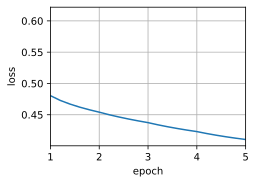

In [104]:
# 开始训练
lr, num_epochs = 0.002, 5
train(net, data_iter, lr, num_epochs)


In [105]:
# 14.4.4. 应用词嵌入：计算指定词的最近邻相似词
def get_similar_tokens(query_token, k, embed):
    W = embed.weight.data
    x = W[vocab[query_token]]
    # 计算余弦相似度。增加1e-9以防止除0
    cos = torch.mv(W, x) / torch.sqrt(torch.sum(W * W, dim=1) *
                                      torch.sum(x * x) + 1e-9)
    topk = torch.topk(cos, k=k + 1)[1].cpu().numpy().astype('int32')
    for i in topk[1:]:  # 排除输入词
        print(f'cosine sim={float(cos[i]):.3f}: {vocab.to_tokens(i)}')

get_similar_tokens('chip', 3, net[0])


cosine sim=0.682: computer
cosine sim=0.650: microprocessor
cosine sim=0.634: bugs


In [106]:
import collections

symbols = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
           'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z',
           '_', '[UNK]']

In [107]:
raw_token_freqs = {'fast_': 4, 'faster_': 3, 'tall_': 5, 'taller_': 4}
token_freqs = {}
for token, freq in raw_token_freqs.items():
    token_freqs[' '.join(list(token))] = raw_token_freqs[token]
token_freqs

{'f a s t _': 4, 'f a s t e r _': 3, 't a l l _': 5, 't a l l e r _': 4}

In [108]:
def get_max_freq_pair(token_freqs):
    pairs = collections.defaultdict(int)
    for token, freq in token_freqs.items():
        symbols = token.split()
        for i in range(len(symbols) - 1):
            # “pairs”的键是两个连续符号的元组
            pairs[symbols[i], symbols[i + 1]] += freq
    return max(pairs, key=pairs.get)  # 具有最大值的“pairs”键

In [109]:
def merge_symbols(max_freq_pair, token_freqs, symbols):
    symbols.append(''.join(max_freq_pair))
    new_token_freqs = dict()
    for token, freq in token_freqs.items():
        new_token = token.replace(' '.join(max_freq_pair),
                                  ''.join(max_freq_pair))
        new_token_freqs[new_token] = token_freqs[token]
    return new_token_freqs

In [110]:
num_merges = 10
for i in range(num_merges):
    max_freq_pair = get_max_freq_pair(token_freqs)
    token_freqs = merge_symbols(max_freq_pair, token_freqs, symbols)
    print(f'合并# {i+1}:',max_freq_pair)

合并# 1: ('t', 'a')
合并# 2: ('ta', 'l')
合并# 3: ('tal', 'l')
合并# 4: ('f', 'a')
合并# 5: ('fa', 's')
合并# 6: ('fas', 't')
合并# 7: ('e', 'r')
合并# 8: ('er', '_')
合并# 9: ('tall', '_')
合并# 10: ('fast', '_')


In [111]:
symbols

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '_',
 '[UNK]',
 'ta',
 'tal',
 'tall',
 'fa',
 'fas',
 'fast',
 'er',
 'er_',
 'tall_',
 'fast_']

In [112]:
token_freqs

{'fast_': 4, 'fast er_': 3, 'tall_': 5, 'tall er_': 4}

In [113]:
def segment_BPE(tokens, symbols):
    outputs = []
    for token in tokens:
        start, end = 0, len(token)
        cur_output = []
        # 具有符号中可能最长子字的词元段
        while start < len(token) and start < end:
            if token[start: end] in symbols:
                cur_output.append(token[start: end])
                start = end
                end = len(token)
            else:
                end -= 1
        if start < len(token):
            cur_output.append('[UNK]')
        outputs.append(' '.join(cur_output))
    return outputs

In [114]:
tokens = ['tallest_', 'fatter_']
segment_BPE(tokens, symbols)

['tall e s t _', 'fa t t er_']

In [115]:
#@save
DATA_HUB['glove.6b.50d'] = (DATA_URL + 'glove.6B.50d.zip',
                                '0b8703943ccdb6eb788e6f091b8946e82231bc4d')

#@save
DATA_HUB['glove.6b.100d'] = (DATA_URL + 'glove.6B.100d.zip',
                                 'cd43bfb07e44e6f27cbcc7bc9ae3d80284fdaf5a')

#@save
DATA_HUB['glove.42b.300d'] = (DATA_URL + 'glove.42B.300d.zip',
                                  'b5116e234e9eb9076672cfeabf5469f3eec904fa')

#@save
DATA_HUB['wiki.en'] = (DATA_URL + 'wiki.en.zip',
                           'c1816da3821ae9f43899be655002f6c723e91b88')

In [116]:
#@save
class TokenEmbedding:
    """GloVe嵌入"""
    def __init__(self, embedding_name):
        self.idx_to_token, self.idx_to_vec = self._load_embedding(
            embedding_name)
        self.unknown_idx = 0
        self.token_to_idx = {token: idx for idx, token in
                             enumerate(self.idx_to_token)}

    def _load_embedding(self, embedding_name):
        idx_to_token, idx_to_vec = ['<unk>'], []
        data_dir = download_extract(embedding_name)
        # GloVe网站：https://nlp.stanford.edu/projects/glove/
        # fastText网站：https://fasttext.cc/
        with open(os.path.join(data_dir, 'vec.txt'), 'r') as f:
            for line in f:
                elems = line.rstrip().split(' ')
                token, elems = elems[0], [float(elem) for elem in elems[1:]]
                # 跳过标题信息，例如fastText中的首行
                if len(elems) > 1:
                    idx_to_token.append(token)
                    idx_to_vec.append(elems)
        idx_to_vec = [[0] * len(idx_to_vec[0])] + idx_to_vec
        return idx_to_token, torch.tensor(idx_to_vec)

    def __getitem__(self, tokens):
        indices = [self.token_to_idx.get(token, self.unknown_idx)
                   for token in tokens]
        vecs = self.idx_to_vec[torch.tensor(indices)]
        return vecs

    def __len__(self):
        return len(self.idx_to_token)

In [117]:
glove_6b50d = TokenEmbedding('glove.6b.50d')

In [118]:
len(glove_6b50d)

400001

In [119]:
glove_6b50d.token_to_idx['beautiful'], glove_6b50d.idx_to_token[3367]

(3367, 'beautiful')

In [120]:
def knn(W, x, k):
    # 增加1e-9以获得数值稳定性
    cos = torch.mv(W, x.reshape(-1,)) / (
        torch.sqrt(torch.sum(W * W, axis=1) + 1e-9) *
        torch.sqrt((x * x).sum()))
    _, topk = torch.topk(cos, k=k)
    return topk, [cos[int(i)] for i in topk]

In [121]:
def get_similar_tokens(query_token, k, embed):
    topk, cos = knn(embed.idx_to_vec, embed[[query_token]], k + 1)
    for i, c in zip(topk[1:], cos[1:]):  # 排除输入词
        print(f'{embed.idx_to_token[int(i)]}：cosine相似度={float(c):.3f}')

In [122]:
get_similar_tokens('chip', 3, glove_6b50d)

chips：cosine相似度=0.856
intel：cosine相似度=0.749
electronics：cosine相似度=0.749


In [123]:
def get_analogy(token_a, token_b, token_c, embed):
    vecs = embed[[token_a, token_b, token_c]]
    x = vecs[1] - vecs[0] + vecs[2]
    topk, cos = knn(embed.idx_to_vec, x, 1)
    return embed.idx_to_token[int(topk[0])]  # 删除未知词

In [124]:
get_analogy('man', 'woman', 'son', glove_6b50d)

'daughter'

In [125]:
#@save
def get_tokens_and_segments(tokens_a, tokens_b=None):
    """获取输入序列的词元及其片段索引"""
    tokens = ['<cls>'] + tokens_a + ['<sep>']
    # 0和1分别标记片段A和B
    segments = [0] * (len(tokens_a) + 2)
    if tokens_b is not None:
        tokens += tokens_b + ['<sep>']
        segments += [1] * (len(tokens_b) + 1)
    return tokens, segments

In [126]:
import math
import torch
from torch import nn

#@save
def sequence_mask(X, valid_len, value=0):
    maxlen = X.size(1)
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

#@save
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

#@save
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

#@save
def transpose_qkv(X, num_heads):
    """为了多注意力头的并行计算而变换形状"""
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])

#@save
def transpose_output(X, num_heads):
    """逆转transpose_qkv函数的操作"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

#@save
class MultiHeadAttention(nn.Module):
    """多头注意力"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)
        output = self.attention(queries, keys, values, valid_lens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

#@save
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs, **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

#@save
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

#@save
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [127]:
#@save
class BERTEncoder(nn.Module):
    """BERT编码器"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(f"{i}", EncoderBlock(
                key_size, query_size, value_size, num_hiddens, norm_shape,
                ffn_num_input, ffn_num_hiddens, num_heads, dropout, True))
        # 在BERT中，位置嵌入是可学习的，因此我们创建一个足够长的位置嵌入参数
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len,
                                                      num_hiddens))

    def forward(self, tokens, segments, valid_lens):
        # 在以下代码段中，X的形状保持不变：（批量大小，最大序列长度，num_hiddens）
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding.data[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

In [128]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
norm_shape, ffn_num_input, num_layers, dropout = [768], 768, 2, 0.2
encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape, ffn_num_input,
                      ffn_num_hiddens, num_heads, num_layers, dropout)

In [129]:
tokens = torch.randint(0, vocab_size, (2, 8))
segments = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 1, 1, 1, 1, 1]])
encoded_X = encoder(tokens, segments, None)
encoded_X.shape

torch.Size([2, 8, 768])

In [130]:
#@save
class MaskLM(nn.Module):
    """BERT的掩蔽语言模型任务"""
    def __init__(self, vocab_size, num_hiddens, num_inputs=768, **kwargs):
        super(MaskLM, self).__init__(**kwargs)
        self.mlp = nn.Sequential(nn.Linear(num_inputs, num_hiddens),
                                 nn.ReLU(),
                                 nn.LayerNorm(num_hiddens),
                                 nn.Linear(num_hiddens, vocab_size))

    def forward(self, X, pred_positions):
        num_pred_positions = pred_positions.shape[1]
        pred_positions = pred_positions.reshape(-1)
        batch_size = X.shape[0]
        batch_idx = torch.arange(0, batch_size)
        # 假设batch_size=2，num_pred_positions=3
        # 那么batch_idx是np.array（[0,0,0,1,1,1]）
        batch_idx = torch.repeat_interleave(batch_idx, num_pred_positions)
        masked_X = X[batch_idx, pred_positions]
        masked_X = masked_X.reshape((batch_size, num_pred_positions, -1))
        mlm_Y_hat = self.mlp(masked_X)
        return mlm_Y_hat

In [131]:
mlm = MaskLM(vocab_size, num_hiddens)
mlm_positions = torch.tensor([[1, 5, 2], [6, 1, 5]])
mlm_Y_hat = mlm(encoded_X, mlm_positions)
mlm_Y_hat.shape

torch.Size([2, 3, 10000])

In [132]:
mlm_Y = torch.tensor([[7, 8, 9], [10, 20, 30]])
loss = nn.CrossEntropyLoss(reduction='none')
mlm_l = loss(mlm_Y_hat.reshape((-1, vocab_size)), mlm_Y.reshape(-1))
mlm_l

tensor([8.5798, 9.0740, 9.9177, 9.9797, 9.4654, 8.7569],
       grad_fn=<NllLossBackward0>)

In [133]:
#@save
class NextSentencePred(nn.Module):
    """BERT的下一句预测任务"""
    def __init__(self, num_inputs, **kwargs):
        super(NextSentencePred, self).__init__(**kwargs)
        self.output = nn.Linear(num_inputs, 2)

    def forward(self, X):
        # X的形状：(batchsize,num_hiddens)
        return self.output(X)

In [134]:
encoded_X = torch.flatten(encoded_X, start_dim=1)
# NSP的输入形状:(batchsize，num_hiddens)
nsp = NextSentencePred(encoded_X.shape[-1])
nsp_Y_hat = nsp(encoded_X)
nsp_Y_hat

tensor([[ 0.6455,  0.3003],
        [ 0.8340, -0.5172]], grad_fn=<AddmmBackward0>)

In [135]:
#@save
class BERTModel(nn.Module):
    """BERT模型"""
    def __init__(self, vocab_size, num_hiddens, norm_shape, ffn_num_input,
                 ffn_num_hiddens, num_heads, num_layers, dropout,
                 max_len=1000, key_size=768, query_size=768, value_size=768,
                 hid_in_features=768, mlm_in_features=768,
                 nsp_in_features=768):
        super(BERTModel, self).__init__()
        self.encoder = BERTEncoder(vocab_size, num_hiddens, norm_shape,
                    ffn_num_input, ffn_num_hiddens, num_heads, num_layers,
                    dropout, max_len=max_len, key_size=key_size,
                    query_size=query_size, value_size=value_size)
        self.hidden = nn.Sequential(nn.Linear(hid_in_features, num_hiddens),
                                    nn.Tanh())
        self.mlm = MaskLM(vocab_size, num_hiddens, mlm_in_features)
        self.nsp = NextSentencePred(nsp_in_features)

    def forward(self, tokens, segments, valid_lens=None,
                pred_positions=None):
        encoded_X = self.encoder(tokens, segments, valid_lens)
        if pred_positions is not None:
            mlm_Y_hat = self.mlm(encoded_X, pred_positions)
        else:
            mlm_Y_hat = None
        # 用于下一句预测的多层感知机分类器的隐藏层，0是“<cls>”标记的索引
        nsp_Y_hat = self.nsp(self.hidden(encoded_X[:, 0, :]))
        return encoded_X, mlm_Y_hat, nsp_Y_hat

In [136]:
DATA_HUB['wikitext-2'] = (
    'https://s3.amazonaws.com/research.metamind.io/wikitext/'
    'wikitext-2-v1.zip', '3c914d17d80b1459be871a5039ac23e752a53cbe')

def _read_wiki(data_dir):
    file_name = os.path.join(data_dir, 'wiki.train.tokens')
    with open(file_name, 'r') as f:
        lines = f.readlines()
    # 大写字母转换为小写字母
    paragraphs = [line.strip().lower().split(' . ')
                  for line in lines if len(line.split(' . ')) >= 2]
    random.shuffle(paragraphs)
    return paragraphs

In [137]:
#@save
def _get_next_sentence(sentence, next_sentence, paragraphs):
    if random.random() < 0.5:
        is_next = True
    else:
        # paragraphs是三重列表的嵌套
        next_sentence = random.choice(random.choice(paragraphs))
        is_next = False
    return sentence, next_sentence, is_next

In [138]:
#@save
def _get_nsp_data_from_paragraph(paragraph, paragraphs, vocab, max_len):
    nsp_data_from_paragraph = []
    for i in range(len(paragraph) - 1):
        tokens_a, tokens_b, is_next = _get_next_sentence(
            paragraph[i], paragraph[i + 1], paragraphs)
        # 考虑1个'<cls>'词元和2个'<sep>'词元
        if len(tokens_a) + len(tokens_b) + 3 > max_len:
            continue
        tokens, segments = get_tokens_and_segments(tokens_a, tokens_b)
        nsp_data_from_paragraph.append((tokens, segments, is_next))
    return nsp_data_from_paragraph

In [139]:
#@save
def _replace_mlm_tokens(tokens, candidate_pred_positions, num_mlm_preds,
                        vocab):
    # 为遮蔽语言模型的输入创建新的词元副本，其中输入可能包含替换的“<mask>”或随机词元
    mlm_input_tokens = [token for token in tokens]
    pred_positions_and_labels = []
    # 打乱后用于在遮蔽语言模型任务中获取15%的随机词元进行预测
    random.shuffle(candidate_pred_positions)
    for mlm_pred_position in candidate_pred_positions:
        if len(pred_positions_and_labels) >= num_mlm_preds:
            break
        masked_token = None
        # 80%的时间：将词替换为“<mask>”词元
        if random.random() < 0.8:
            masked_token = '<mask>'
        else:
            # 10%的时间：保持词不变
            if random.random() < 0.5:
                masked_token = tokens[mlm_pred_position]
            # 10%的时间：用随机词替换该词
            else:
                masked_token = random.choice(vocab.idx_to_token)
        mlm_input_tokens[mlm_pred_position] = masked_token
        pred_positions_and_labels.append(
            (mlm_pred_position, tokens[mlm_pred_position]))
    return mlm_input_tokens, pred_positions_and_labels

In [140]:
#@save
def _get_mlm_data_from_tokens(tokens, vocab):
    candidate_pred_positions = []
    # tokens是一个字符串列表
    for i, token in enumerate(tokens):
        # 在遮蔽语言模型任务中不会预测特殊词元
        if token in ['<cls>', '<sep>']:
            continue
        candidate_pred_positions.append(i)
    # 遮蔽语言模型任务中预测15%的随机词元
    num_mlm_preds = max(1, round(len(tokens) * 0.15))
    mlm_input_tokens, pred_positions_and_labels = _replace_mlm_tokens(
        tokens, candidate_pred_positions, num_mlm_preds, vocab)
    pred_positions_and_labels = sorted(pred_positions_and_labels,
                                       key=lambda x: x[0])
    pred_positions = [v[0] for v in pred_positions_and_labels]
    mlm_pred_labels = [v[1] for v in pred_positions_and_labels]
    return vocab[mlm_input_tokens], pred_positions, vocab[mlm_pred_labels]

In [141]:
#@save
def _pad_bert_inputs(examples, max_len, vocab):
    max_num_mlm_preds = round(max_len * 0.15)
    all_token_ids, all_segments, valid_lens,  = [], [], []
    all_pred_positions, all_mlm_weights, all_mlm_labels = [], [], []
    nsp_labels = []
    for (token_ids, pred_positions, mlm_pred_label_ids, segments,
         is_next) in examples:
        all_token_ids.append(torch.tensor(token_ids + [vocab['<pad>']] * (
            max_len - len(token_ids)), dtype=torch.long))
        all_segments.append(torch.tensor(segments + [0] * (
            max_len - len(segments)), dtype=torch.long))
        # valid_lens不包括'<pad>'的计数
        valid_lens.append(torch.tensor(len(token_ids), dtype=torch.float32))
        all_pred_positions.append(torch.tensor(pred_positions + [0] * (
            max_num_mlm_preds - len(pred_positions)), dtype=torch.long))
        # 填充词元的预测将通过乘以0权重在损失中过滤掉
        all_mlm_weights.append(
            torch.tensor([1.0] * len(mlm_pred_label_ids) + [0.0] * (
                max_num_mlm_preds - len(pred_positions)),
                dtype=torch.float32))
        all_mlm_labels.append(torch.tensor(mlm_pred_label_ids + [0] * (
            max_num_mlm_preds - len(mlm_pred_label_ids)), dtype=torch.long))
        nsp_labels.append(torch.tensor(is_next, dtype=torch.long))
    return (all_token_ids, all_segments, valid_lens, all_pred_positions,
            all_mlm_weights, all_mlm_labels, nsp_labels)

In [142]:
#@save
class _WikiTextDataset(torch.utils.data.Dataset):
    def __init__(self, paragraphs, max_len):
        # 输入paragraphs[i]是代表段落的句子字符串列表；
        # 而输出paragraphs[i]是代表段落的句子列表，其中每个句子都是词元列表
        paragraphs = [tokenize(
            paragraph, token='word') for paragraph in paragraphs]
        sentences = [sentence for paragraph in paragraphs
                     for sentence in paragraph]
        self.vocab = Vocab(sentences, min_freq=5, reserved_tokens=[
            '<pad>', '<mask>', '<cls>', '<sep>'])
        # 获取下一句子预测任务的数据
        examples = []
        for paragraph in paragraphs:
            examples.extend(_get_nsp_data_from_paragraph(
                paragraph, paragraphs, self.vocab, max_len))
        # 获取遮蔽语言模型任务的数据
        examples = [(_get_mlm_data_from_tokens(tokens, self.vocab)
                      + (segments, is_next))
                     for tokens, segments, is_next in examples]
        # 填充输入
        (self.all_token_ids, self.all_segments, self.valid_lens,
         self.all_pred_positions, self.all_mlm_weights,
         self.all_mlm_labels, self.nsp_labels) = _pad_bert_inputs(
            examples, max_len, self.vocab)

    def __getitem__(self, idx):
        return (self.all_token_ids[idx], self.all_segments[idx],
                self.valid_lens[idx], self.all_pred_positions[idx],
                self.all_mlm_weights[idx], self.all_mlm_labels[idx],
                self.nsp_labels[idx])

    def __len__(self):
        return len(self.all_token_ids)

In [143]:
#@save
def load_data_wiki(batch_size, max_len):
    """加载WikiText-2数据集"""
    num_workers = get_dataloader_workers()
    data_dir = download_extract('wikitext-2', 'wikitext-2')
    paragraphs = _read_wiki(data_dir)
    train_set = _WikiTextDataset(paragraphs, max_len)
    train_iter = torch.utils.data.DataLoader(train_set, batch_size,
                                        shuffle=True, num_workers=num_workers)
    return train_iter, train_set.vocab

In [145]:
# 1. 词元化切分函数（补在 Cell 70 顶部或单独单元格）
def tokenize(lines, token='word'):
    """将文本行拆分为单词或字符词元"""
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('错误：未知词元类型：' + token)

# 2. 序列填充与截断（补在 Cell 82）
def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

# 3. 数据集迭代器加载器（补在 Cell 82）
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个 PyTorch 数据迭代器"""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

# 4. 图表大小配置（补在 Cell 30 / Cell 82）
def set_figsize(figsize=(3.5, 2.5)):
    """设置 matplotlib 的图表大小"""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

# 5. 模型多卡/单卡训练函数（补在 Cell 94 顶部）
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, torch.nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, (list, tuple)):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

def train_batch_ch13(net, X, y, loss, trainer, devices):
    if isinstance(X, (list, tuple)):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    return l.sum().detach(), accuracy(pred.detach(), y)

def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices=None):
    if devices is None:
        devices = try_all_gpus()
    if isinstance(devices, torch.device):
        devices = [devices]
    if len(devices) > 1 and all(d.type == 'cuda' for d in devices):
        net = nn.DataParallel(net, device_ids=devices)
    net = net.to(devices[0])
    timer, num_batches = Timer(), len(train_iter)
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        metric = Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % max(1, num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3], None))
        test_acc = evaluate_accuracy_gpu(net, test_iter, devices[0])
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc {metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(devices)}')

In [146]:
batch_size, max_len = 512, 64
train_iter, vocab = load_data_wiki(batch_size, max_len)

for (tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X,
     mlm_Y, nsp_y) in train_iter:
    print(tokens_X.shape, segments_X.shape, valid_lens_x.shape,
          pred_positions_X.shape, mlm_weights_X.shape, mlm_Y.shape,
          nsp_y.shape)
    break

torch.Size([512, 64]) torch.Size([512, 64]) torch.Size([512]) torch.Size([512, 10]) torch.Size([512, 10]) torch.Size([512, 10]) torch.Size([512])


In [147]:
len(vocab)

20256

In [148]:
batch_size, max_len = 512, 64
train_iter, vocab = load_data_wiki(batch_size, max_len)

In [149]:
net = BERTModel(len(vocab), num_hiddens=128, norm_shape=[128],
                    ffn_num_input=128, ffn_num_hiddens=256, num_heads=2,
                    num_layers=2, dropout=0.2, key_size=128, query_size=128,
                    value_size=128, hid_in_features=128, mlm_in_features=128,
                    nsp_in_features=128)
devices = try_all_gpus()
loss = nn.CrossEntropyLoss()

In [150]:
#@save
def _get_batch_loss_bert(net, loss, vocab_size, tokens_X,
                         segments_X, valid_lens_x,
                         pred_positions_X, mlm_weights_X,
                         mlm_Y, nsp_y):
    # 前向传播
    _, mlm_Y_hat, nsp_Y_hat = net(tokens_X, segments_X,
                                  valid_lens_x.reshape(-1),
                                  pred_positions_X)
    # 计算遮蔽语言模型损失
    mlm_l = loss(mlm_Y_hat.reshape(-1, vocab_size), mlm_Y.reshape(-1)) *\
    mlm_weights_X.reshape(-1, 1)
    mlm_l = mlm_l.sum() / (mlm_weights_X.sum() + 1e-8)
    # 计算下一句子预测任务的损失
    nsp_l = loss(nsp_Y_hat, nsp_y)
    l = mlm_l + nsp_l
    return mlm_l, nsp_l, l

In [151]:
def train_bert(train_iter, net, loss, vocab_size, devices, num_steps):
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    trainer = torch.optim.Adam(net.parameters(), lr=0.01)
    step, timer = 0, Timer()
    animator = Animator(xlabel='step', ylabel='loss',
                            xlim=[1, num_steps], legend=['mlm', 'nsp'])
    # 遮蔽语言模型损失的和，下一句预测任务损失的和，句子对的数量，计数
    metric = Accumulator(4)
    num_steps_reached = False
    while step < num_steps and not num_steps_reached:
        for tokens_X, segments_X, valid_lens_x, pred_positions_X,\
            mlm_weights_X, mlm_Y, nsp_y in train_iter:
            tokens_X = tokens_X.to(devices[0])
            segments_X = segments_X.to(devices[0])
            valid_lens_x = valid_lens_x.to(devices[0])
            pred_positions_X = pred_positions_X.to(devices[0])
            mlm_weights_X = mlm_weights_X.to(devices[0])
            mlm_Y, nsp_y = mlm_Y.to(devices[0]), nsp_y.to(devices[0])
            trainer.zero_grad()
            timer.start()
            mlm_l, nsp_l, l = _get_batch_loss_bert(
                net, loss, vocab_size, tokens_X, segments_X, valid_lens_x,
                pred_positions_X, mlm_weights_X, mlm_Y, nsp_y)
            l.backward()
            trainer.step()
            metric.add(mlm_l, nsp_l, tokens_X.shape[0], 1)
            timer.stop()
            animator.add(step + 1,
                         (metric[0] / metric[3], metric[1] / metric[3]))
            step += 1
            if step == num_steps:
                num_steps_reached = True
                break

    print(f'MLM loss {metric[0] / metric[3]:.3f}, '
          f'NSP loss {metric[1] / metric[3]:.3f}')
    print(f'{metric[2] / timer.sum():.1f} sentence pairs/sec on '
          f'{str(devices)}')

MLM loss 5.582, NSP loss 0.773
9347.6 sentence pairs/sec on [device(type='cuda', index=0)]


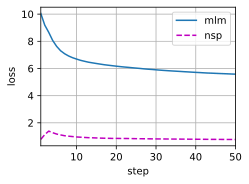

In [152]:
train_bert(train_iter, net, loss, len(vocab), devices, 50)

In [153]:
def get_bert_encoding(net, tokens_a, tokens_b=None):
    tokens, segments = get_tokens_and_segments(tokens_a, tokens_b)
    token_ids = torch.tensor(vocab[tokens], device=devices[0]).unsqueeze(0)
    segments = torch.tensor(segments, device=devices[0]).unsqueeze(0)
    valid_len = torch.tensor(len(tokens), device=devices[0]).unsqueeze(0)
    encoded_X, _, _ = net(token_ids, segments, valid_len)
    return encoded_X

In [154]:
tokens_a = ['a', 'crane', 'is', 'flying']
encoded_text = get_bert_encoding(net, tokens_a)
# 词元：'<cls>','a','crane','is','flying','<sep>'
encoded_text_cls = encoded_text[:, 0, :]
encoded_text_crane = encoded_text[:, 2, :]
encoded_text.shape, encoded_text_cls.shape, encoded_text_crane[0][:3]

(torch.Size([1, 6, 128]),
 torch.Size([1, 128]),
 tensor([-0.1435,  2.8820,  0.9701], device='cuda:0', grad_fn=<SliceBackward0>))

In [155]:
tokens_a, tokens_b = ['a', 'crane', 'driver', 'came'], ['he', 'just', 'left']
encoded_pair = get_bert_encoding(net, tokens_a, tokens_b)
# 词元：'<cls>','a','crane','driver','came','<sep>','he','just',
# 'left','<sep>'
encoded_pair_cls = encoded_pair[:, 0, :]
encoded_pair_crane = encoded_pair[:, 2, :]
encoded_pair.shape, encoded_pair_cls.shape, encoded_pair_crane[0][:3]

(torch.Size([1, 10, 128]),
 torch.Size([1, 128]),
 tensor([-2.1835,  2.9588,  1.1266], device='cuda:0', grad_fn=<SliceBackward0>))

In [157]:
import os

# 1. 明确指定 IMDb 数据集路径（本地 data 目录下已存在 aclImdb）
DATA_HUB['aclImdb'] = (
    'https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz',
    '01ada507287d82875905620988597833ad4e0903')

# Keep many IMDb text files on the interpreter's native filesystem.
imdb_cache_dir = os.path.join(os.path.expanduser('~'), '.cache', 'd2l')
data_dir = download_extract('aclImdb', 'aclImdb', cache_dir=imdb_cache_dir)


# 2. 补齐后续单元格依赖的辅助函数（防止后续单元格报 NameError）
#@save
def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

#@save
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

#@save
def set_figsize(figsize=(3.5, 2.5)):
    """设置matplotlib的图表大小"""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

# 3. 读取 IMDb 数据集并加载训练集
#@save
def read_imdb(data_dir, is_train):
    """读取IMDb数据集的文本序列和标签"""
    data, labels = [], []
    for label in ('pos', 'neg'):
        folder_name = os.path.join(data_dir, 'train' if is_train else 'test',
                                   label)
        for file in os.listdir(folder_name):
            with open(os.path.join(folder_name, file), 'rb') as f:
                review = f.read().decode('utf-8').replace('\n', '')
                data.append(review)
                labels.append(1 if label == 'pos' else 0)
    return data, labels

train_data = read_imdb(data_dir, is_train=True)
print('训练集数目：', len(train_data[0]))
for x, y in zip(train_data[0][:3], train_data[1][:3]):
    print('标签：', y, 'review:', x[0:60])

训练集数目： 25000
标签： 1 review: Bromwell High is a cartoon comedy. It ran at the same time a
标签： 1 review: Homelessness (or Houselessness as George Carlin stated) has 
标签： 1 review: Brilliant over-acting by Lesley Ann Warren. Best dramatic ho


In [158]:
train_tokens = tokenize(train_data[0], token='word')
vocab = Vocab(train_tokens, min_freq=5, reserved_tokens=['<pad>'])

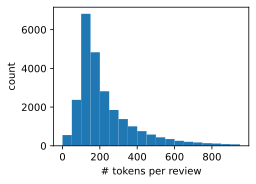

In [159]:
set_figsize()
plt.xlabel('# tokens per review')
plt.ylabel('count')
plt.hist([len(line) for line in train_tokens], bins=range(0, 1000, 50));

In [160]:
num_steps = 500  # 序列长度
train_features = torch.tensor([truncate_pad(
    vocab[line], num_steps, vocab['<pad>']) for line in train_tokens])
print(train_features.shape)

torch.Size([25000, 500])


In [161]:
train_iter = load_array((train_features,
    torch.tensor(train_data[1])), 64)

for X, y in train_iter:
    print('X:', X.shape, ', y:', y.shape)
    break
print('小批量数目：', len(train_iter))

X: torch.Size([64, 500]) , y: torch.Size([64])
小批量数目： 391


In [162]:
#@save
def load_data_imdb(batch_size, num_steps=500):
    """返回数据迭代器和IMDb评论数据集的词表"""
    # data_dir = download_extract('aclImdb', 'aclImdb')
    data_dir = download_extract('aclImdb', 'aclImdb',
                                cache_dir=imdb_cache_dir)
    train_data = read_imdb(data_dir, True)
    test_data = read_imdb(data_dir, False)
    train_tokens = tokenize(train_data[0], token='word')
    test_tokens = tokenize(test_data[0], token='word')
    vocab = Vocab(train_tokens, min_freq=5)
    train_features = torch.tensor([truncate_pad(
        vocab[line], num_steps, vocab['<pad>']) for line in train_tokens])
    test_features = torch.tensor([truncate_pad(
        vocab[line], num_steps, vocab['<pad>']) for line in test_tokens])
    train_iter = load_array((train_features, torch.tensor(train_data[1])),
                                batch_size)
    test_iter = load_array((test_features, torch.tensor(test_data[1])),
                               batch_size,
                               is_train=False)
    return train_iter, test_iter, vocab

In [163]:
batch_size = 64
train_iter, test_iter, vocab = load_data_imdb(batch_size)

In [164]:
class BiRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens,
                 num_layers, **kwargs):
        super(BiRNN, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 将bidirectional设置为True以获取双向循环神经网络
        self.encoder = nn.LSTM(embed_size, num_hiddens, num_layers=num_layers,
                                bidirectional=True)
        self.decoder = nn.Linear(4 * num_hiddens, 2)

    def forward(self, inputs):
        # inputs的形状是（批量大小，时间步数）
        # 因为长短期记忆网络要求其输入的第一个维度是时间维，
        # 所以在获得词元表示之前，输入会被转置。
        # 输出形状为（时间步数，批量大小，词向量维度）
        embeddings = self.embedding(inputs.T)
        self.encoder.flatten_parameters()
        # 返回上一个隐藏层在不同时间步的隐状态，
        # outputs的形状是（时间步数，批量大小，2*隐藏单元数）
        outputs, _ = self.encoder(embeddings)
        # 连结初始和最终时间步的隐状态，作为全连接层的输入，
        # 其形状为（批量大小，4*隐藏单元数）
        encoding = torch.cat((outputs[0], outputs[-1]), dim=1)
        outs = self.decoder(encoding)
        return outs

In [165]:
embed_size, num_hiddens, num_layers = 100, 100, 2
devices = try_all_gpus()
net = BiRNN(len(vocab), embed_size, num_hiddens, num_layers)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
    if type(m) == nn.LSTM:
        for param in m._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(m._parameters[param])
net.apply(init_weights);

In [166]:
glove_embedding = TokenEmbedding('glove.6b.100d')

In [167]:
embeds = glove_embedding[vocab.idx_to_token]
embeds.shape

torch.Size([49346, 100])

In [168]:
net.embedding.weight.data.copy_(embeds)
net.embedding.weight.requires_grad = False

loss 0.320, train acc 0.864, test acc 0.861
1797.5 examples/sec on [device(type='cuda', index=0)]


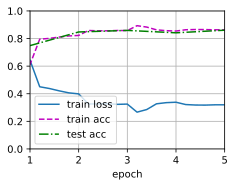

In [169]:
lr, num_epochs = 0.01, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
    devices)

In [171]:
#@save
def predict_sentiment(net, vocab, sequence):
    """预测文本序列的情感"""
    sequence = torch.tensor(vocab[sequence.split()], device=try_gpu())
    label = torch.argmax(net(sequence.reshape(1, -1)), dim=1)
    return 'positive' if label == 1 else 'negative'

In [172]:
predict_sentiment(net, vocab, 'this movie is so great')

'positive'

In [173]:
def corr1d(X, K):
    w = K.shape[0]
    Y = torch.zeros((X.shape[0] - w + 1))
    for i in range(Y.shape[0]):
        Y[i] = (X[i: i + w] * K).sum()
    return Y

In [175]:
X, K = torch.tensor([0, 1, 2, 3, 4, 5, 6]), torch.tensor([1, 2])
corr1d(X, K)

tensor([ 2.,  5.,  8., 11., 14., 17.])

In [176]:
def corr1d_multi_in(X, K):
    # 首先，遍历'X'和'K'的第0维（通道维）。然后，把它们加在一起
    return sum(corr1d(x, k) for x, k in zip(X, K))

X = torch.tensor([[0, 1, 2, 3, 4, 5, 6],
              [1, 2, 3, 4, 5, 6, 7],
              [2, 3, 4, 5, 6, 7, 8]])
K = torch.tensor([[1, 2], [3, 4], [-1, -3]])
corr1d_multi_in(X, K)

tensor([ 2.,  8., 14., 20., 26., 32.])

In [177]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_size, kernel_sizes, num_channels,
                 **kwargs):
        super(TextCNN, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 这个嵌入层不需要训练
        self.constant_embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(0.5)
        self.decoder = nn.Linear(sum(num_channels), 2)
        # 最大时间汇聚层没有参数，因此可以共享此实例
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.relu = nn.ReLU()
        # 创建多个一维卷积层
        self.convs = nn.ModuleList()
        for c, k in zip(num_channels, kernel_sizes):
            self.convs.append(nn.Conv1d(2 * embed_size, c, k))

    def forward(self, inputs):
        # 沿着向量维度将两个嵌入层连结起来，
        # 每个嵌入层的输出形状都是（批量大小，词元数量，词元向量维度）连结起来
        embeddings = torch.cat((
            self.embedding(inputs), self.constant_embedding(inputs)), dim=2)
        # 根据一维卷积层的输入格式，重新排列张量，以便通道作为第2维
        embeddings = embeddings.permute(0, 2, 1)
        # 每个一维卷积层在最大时间汇聚层合并后，获得的张量形状是（批量大小，通道数，1）
        # 删除最后一个维度并沿通道维度连结
        encoding = torch.cat([
            torch.squeeze(self.relu(self.pool(conv(embeddings))), dim=-1)
            for conv in self.convs], dim=1)
        outputs = self.decoder(self.dropout(encoding))
        return outputs

In [178]:
embed_size, kernel_sizes, nums_channels = 100, [3, 4, 5], [100, 100, 100]
devices = try_all_gpus()
net = TextCNN(len(vocab), embed_size, kernel_sizes, nums_channels)

def init_weights(m):
    if type(m) in (nn.Linear, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights);

In [179]:
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.data.copy_(embeds)
net.constant_embedding.weight.requires_grad = False

loss 0.071, train acc 0.976, test acc 0.868
5888.4 examples/sec on [device(type='cuda', index=0)]


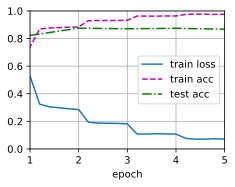

In [181]:
lr, num_epochs = 0.001, 5
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

In [182]:
predict_sentiment(net, vocab, 'this movie is so great')

'positive'

In [183]:
DATA_HUB['SNLI'] = (
    'https://nlp.stanford.edu/projects/snli/snli_1.0.zip',
    '9fcde07509c7e87ec61c640c1b2753d9041758e4')

data_dir = download_extract('SNLI')

In [184]:
#@save
def read_snli(data_dir, is_train):
    """将SNLI数据集解析为前提、假设和标签"""
    def extract_text(s):
        # 删除我们不会使用的信息
        s = re.sub('\\(', '', s)
        s = re.sub('\\)', '', s)
        # 用一个空格替换两个或多个连续的空格
        s = re.sub('\\s{2,}', ' ', s)
        return s.strip()
    label_set = {'entailment': 0, 'contradiction': 1, 'neutral': 2}
    file_name = os.path.join(data_dir, 'snli_1.0_train.txt'
                             if is_train else 'snli_1.0_test.txt')
    with open(file_name, 'r') as f:
        rows = [row.split('\t') for row in f.readlines()[1:]]
    premises = [extract_text(row[1]) for row in rows if row[0] in label_set]
    hypotheses = [extract_text(row[2]) for row in rows if row[0] \
                in label_set]
    labels = [label_set[row[0]] for row in rows if row[0] in label_set]
    return premises, hypotheses, labels

In [186]:
import re
train_data = read_snli(data_dir, is_train=True)
for x0, x1, y in zip(train_data[0][:3], train_data[1][:3], train_data[2][:3]):
    print('前提：', x0)
    print('假设：', x1)
    print('标签：', y)

前提： A person on a horse jumps over a broken down airplane .
假设： A person is training his horse for a competition .
标签： 2
前提： A person on a horse jumps over a broken down airplane .
假设： A person is at a diner , ordering an omelette .
标签： 1
前提： A person on a horse jumps over a broken down airplane .
假设： A person is outdoors , on a horse .
标签： 0


In [187]:
test_data = read_snli(data_dir, is_train=False)
for data in [train_data, test_data]:
    print([[row for row in data[2]].count(i) for i in range(3)])

[183416, 183187, 182764]
[3368, 3237, 3219]


In [191]:
#@save
class SNLIDataset(torch.utils.data.Dataset):
    """用于加载SNLI数据集的自定义数据集"""
    def __init__(self, dataset, num_steps, vocab=None):
        self.num_steps = num_steps
        all_premise_tokens = tokenize(dataset[0])
        all_hypothesis_tokens = tokenize(dataset[1])
        if vocab is None:
            self.vocab = Vocab(all_premise_tokens + \
                all_hypothesis_tokens, min_freq=5, reserved_tokens=['<pad>'])
        else:
            self.vocab = vocab
        self.premises = self._pad(all_premise_tokens)
        self.hypotheses = self._pad(all_hypothesis_tokens)
        self.labels = torch.tensor(dataset[2])
        print('read ' + str(len(self.premises)) + ' examples')

    def _pad(self, lines):
        return torch.tensor([truncate_pad(
            self.vocab[line], self.num_steps, self.vocab['<pad>'])
                         for line in lines])

    def __getitem__(self, idx):
        return (self.premises[idx], self.hypotheses[idx]), self.labels[idx]

    def __len__(self):
        return len(self.premises)

In [192]:
#@save
def load_data_snli(batch_size, num_steps=50):
    """下载SNLI数据集并返回数据迭代器和词表"""
    num_workers = get_dataloader_workers()
    data_dir = download_extract('SNLI')
    train_data = read_snli(data_dir, True)
    test_data = read_snli(data_dir, False)
    train_set = SNLIDataset(train_data, num_steps)
    test_set = SNLIDataset(test_data, num_steps, train_set.vocab)
    train_iter = torch.utils.data.DataLoader(train_set, batch_size,
                                             shuffle=True,
                                             num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(test_set, batch_size,
                                            shuffle=False,
                                            num_workers=num_workers)
    return train_iter, test_iter, train_set.vocab

In [193]:
train_iter, test_iter, vocab = load_data_snli(128, 50)
len(vocab)

read 549367 examples
read 9824 examples


18678

In [194]:
for X, Y in train_iter:
    print(X[0].shape)
    print(X[1].shape)
    print(Y.shape)
    break

torch.Size([128, 50])
torch.Size([128, 50])
torch.Size([128])


In [195]:
def mlp(num_inputs, num_hiddens, flatten):
    net = []
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_inputs, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    net.append(nn.Dropout(0.2))
    net.append(nn.Linear(num_hiddens, num_hiddens))
    net.append(nn.ReLU())
    if flatten:
        net.append(nn.Flatten(start_dim=1))
    return nn.Sequential(*net)

In [206]:
import torch.nn.functional as F
class Attend(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Attend, self).__init__(**kwargs)
        self.f = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B):
        # A/B的形状：（批量大小，序列A/B的词元数，embed_size）
        # f_A/f_B的形状：（批量大小，序列A/B的词元数，num_hiddens）
        f_A = self.f(A)
        f_B = self.f(B)
        # e的形状：（批量大小，序列A的词元数，序列B的词元数）
        e = torch.bmm(f_A, f_B.permute(0, 2, 1))
        # beta的形状：（批量大小，序列A的词元数，embed_size），
        # 意味着序列B被软对齐到序列A的每个词元(beta的第1个维度)
        beta = torch.bmm(F.softmax(e, dim=-1), B)
        # beta的形状：（批量大小，序列B的词元数，embed_size），
        # 意味着序列A被软对齐到序列B的每个词元(alpha的第1个维度)
        alpha = torch.bmm(F.softmax(e.permute(0, 2, 1), dim=-1), A)
        return beta, alpha

In [207]:
class Compare(nn.Module):
    def __init__(self, num_inputs, num_hiddens, **kwargs):
        super(Compare, self).__init__(**kwargs)
        self.g = mlp(num_inputs, num_hiddens, flatten=False)

    def forward(self, A, B, beta, alpha):
        V_A = self.g(torch.cat([A, beta], dim=2))
        V_B = self.g(torch.cat([B, alpha], dim=2))
        return V_A, V_B

In [208]:
class Aggregate(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_outputs, **kwargs):
        super(Aggregate, self).__init__(**kwargs)
        self.h = mlp(num_inputs, num_hiddens, flatten=True)
        self.linear = nn.Linear(num_hiddens, num_outputs)

    def forward(self, V_A, V_B):
        # 对两组比较向量分别求和
        V_A = V_A.sum(dim=1)
        V_B = V_B.sum(dim=1)
        # 将两个求和结果的连结送到多层感知机中
        Y_hat = self.linear(self.h(torch.cat([V_A, V_B], dim=1)))
        return Y_hat

In [209]:
class DecomposableAttention(nn.Module):
    def __init__(self, vocab, embed_size, num_hiddens, num_inputs_attend=100,
                 num_inputs_compare=200, num_inputs_agg=400, **kwargs):
        super(DecomposableAttention, self).__init__(**kwargs)
        self.embedding = nn.Embedding(len(vocab), embed_size)
        self.attend = Attend(num_inputs_attend, num_hiddens)
        self.compare = Compare(num_inputs_compare, num_hiddens)
        # 有3种可能的输出：蕴涵、矛盾和中性
        self.aggregate = Aggregate(num_inputs_agg, num_hiddens, num_outputs=3)

    def forward(self, X):
        premises, hypotheses = X
        A = self.embedding(premises)
        B = self.embedding(hypotheses)
        beta, alpha = self.attend(A, B)
        V_A, V_B = self.compare(A, B, beta, alpha)
        Y_hat = self.aggregate(V_A, V_B)
        return Y_hat

In [210]:
batch_size, num_steps = 256, 50
train_iter, test_iter, vocab = load_data_snli(batch_size, num_steps)

read 549367 examples
read 9824 examples


In [211]:
embed_size, num_hiddens, devices = 100, 200, try_all_gpus()
net = DecomposableAttention(vocab, embed_size, num_hiddens)
glove_embedding = TokenEmbedding('glove.6b.100d')
embeds = glove_embedding[vocab.idx_to_token]
net.embedding.weight.data.copy_(embeds);

loss 0.495, train acc 0.806, test acc 0.822
26590.2 examples/sec on [device(type='cuda', index=0)]


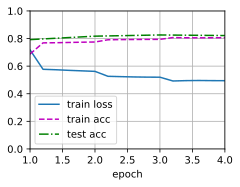

In [213]:
# 修复支持多输入（list/tuple）的批次训练与模型训练函数
#@save
def train_batch_ch13(net, X, y, loss, trainer, devices):
    """用多GPU进行小批量训练（同时支持单输入和多输入 list/tuple）"""
    if isinstance(X, (list, tuple)):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    return l.sum().detach(), accuracy(pred.detach(), y)

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """在指定设备上评估精度（同时支持单输入和多输入）"""
    if isinstance(net, torch.nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, (list, tuple)):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

#@save
def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=None):
    """用多GPU进行模型训练"""
    if devices is None:
        devices = try_all_gpus()
    if isinstance(devices, torch.device):
        devices = [devices]
    if len(devices) > 1 and all(d.type == 'cuda' for d in devices):
        net = nn.DataParallel(net, device_ids=devices)
    net = net.to(devices[0])
    timer, num_batches = Timer(), len(train_iter)
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        metric = Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, devices)
            # 使用 labels.shape[0] 作为样本量，彻底解决 features 是 list 导致的 AttributeError
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % max(1, num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3], None))
        test_acc = evaluate_accuracy_gpu(net, test_iter, devices[0])
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc {metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(devices)}')

# 开始 SNLI 可分解注意力模型训练
lr, num_epochs = 0.001, 4
trainer = torch.optim.Adam(net.parameters(), lr=lr)
loss = nn.CrossEntropyLoss(reduction="none")
train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices)

In [218]:
#@save
def predict_snli(net, vocab, premise, hypothesis):
    """预测前提和假设之间的逻辑关系"""
    net.eval()
    premise = torch.tensor(vocab[premise], device=try_gpu())
    hypothesis = torch.tensor(vocab[hypothesis], device=try_gpu())
    label = torch.argmax(net([premise.reshape((1, -1)),
                           hypothesis.reshape((1, -1))]), dim=1)
    return 'entailment' if label == 0 else 'contradiction' if label == 1 \
            else 'neutral'

In [219]:
predict_snli(net, vocab, ['he', 'is', 'good', '.'], ['he', 'is', 'bad', '.'])

'contradiction'

传统的自然语言推断面临两难：**纯神经网络**擅长模糊语义匹配但缺乏严格的逻辑可解释性与传递性；**离散数学/符号逻辑**具备严格的保真证明能力，但在处理自然语言的多义性与常识表达时极度脆弱。两者的结合主要有以下四种成熟路径：

**1. 自然逻辑与关系代数（Natural Logic & Monotonicity Calculus）**

* **离散数学工具：** 关系代数（Relation Algebra）与单调性演算（Monotonicity Calculus）。
* **核心思路：** 将集合关系离散化为关系代数（如 MacCartney 提出的 7 种自然逻辑关系：等价 $\equiv$、前向蕴涵 $\sqsubset$、反向蕴涵 $\sqsupset$、矛盾 $\wedge$、交替 $\vert{}$ 等）。
* **结合方式：**
* 神经网络负责**局部对齐与语义原子关系预测**（例如判断“狗” $\sqsubset$ “动物”）。
* 离散数学负责**全局推导**：利用句法树的极性（向上单调/向下单调）和**关系复合查找表（Composition Table）**，严格计算整句是否蕴涵。整套推理链具有形式化的单调性证明。



**2. 偏序集与几何格理论（Order Embeddings & Box Embeddings）**

* **离散数学工具：** 偏序集（Poset）与几何包含关系（一般盒集合不等同于布尔格）。
* **核心思路：** 逻辑蕴涵在句子上形成预序；按语义等价取商后才形成偏序（自反性、反对称性、传递性）或集合包含关系（$A \implies B \iff A \subseteq B$）。
* **结合方式：**
* 传统向量只算余弦相似度，无法刻画非对称的蕴涵；
* 模型将词语或句子映射为高维几何空间中的**正锥（Cones）**或**超长方体（Box Embeddings）**。
* 蕴涵直接形式化为高维几何体的容积包含度，天然满足离散偏序的传递律：若 $\text{Box}(A) \subseteq \text{Box}(B)$ 且 $\text{Box}(B) \subseteq \text{Box}(C)$，则必然 $\text{Box}(A) \subseteq \text{Box}(C)$。



**3. 连续松弛与逻辑张量网络（Logic Tensor Networks, LTN）**

* **离散数学工具：** 一阶逻辑（First-Order Logic, FOL）与模糊逻辑 T-norm（如 Product T-norm、Łukasiewicz T-norm）。
* **核心思路：** 将离散逻辑运算（$\land, \lor, \neg, \implies$）通过实数区间的 T-范数平滑转化为可微的代数运算。
* **结合方式：**
* 前提与假设中的实体映射为连续嵌入向量，谓词映射为神经网络判别器。
* 将形式逻辑先验公理（如传递性 $\forall x, y, z: (P(x,y) \land P(y,z)) \implies P(x,z)$）转化为连续损失函数，指导网络参数的端到端梯度更新。



**4. 神经形式语义解析与自动定理证明（Semantic Parsing + SMT Solver）**

* **离散数学工具：** $\lambda$-演算、组合范畴语法（CCG）、SMT/SAT 求解器（如 Z3、Prover9）。
* **核心思路：** 神经模型只负责“翻译”，离散系统负责“求解”。
* **结合方式：**
* 利用神经序列模型将前提文本 $P$ 和假设文本 $H$ 解析为离散的一阶逻辑公式 $\phi(P)$ 和 $\phi(H)$。
* 交由后端的离散定理证明器严格检查蕴涵有效性 $\phi(P) \models \phi(H)$。如果缺少背景常识，再通过神经网络从外部知识库中检索并注入缺失的逻辑公理。

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 序嵌入网络：将自然语言映射到非负偏序空间 R_+^d
class OrderEmbeddingNLI(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, poset_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # 特征提取 Encoder (此处用 GRU 提取时序语义)
        self.encoder = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        # 投影至偏序空间，并通过 ReLU 强制落在非负象限 R_+^d
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, poset_dim),
            nn.ReLU()
        )

    def encode(self, x):
        embeds = self.embedding(x)
        _, h_n = self.encoder(embeds)
        # 映射到非负偏序锥中
        poset_vec = self.proj(h_n.squeeze(0))
        return poset_vec

    @staticmethod
    def energy(u, v):
        """
        计算离散偏序违背程度:
        若 u 蕴涵 v，则要求每个维度 u_k >= v_k，违背量 max(0, v - u) 应为 0
        """
        violation = torch.relu(v - u)
        return torch.sum(violation ** 2, dim=-1)

# 2. 偏序约束损失函数 (Max-Margin Order Loss)
class OrderLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, pos_u, pos_v, neg_u, neg_v):
        # 正样本对 (蕴涵): 违序能量趋向于 0
        loss_pos = OrderEmbeddingNLI.energy(pos_u, pos_v)
        # 负样本对 (不蕴涵/矛盾): 违序能量应至少大于预设间隔 margin
        loss_neg = torch.relu(self.margin - OrderEmbeddingNLI.energy(neg_u, neg_v))
        return (loss_pos + loss_neg).mean()



def run_order_embedding_toy(seed=17):
    """Run the original toy locally without overwriting SNLI vocab/model."""
    with torch.random.fork_rng(devices=list(range(torch.cuda.device_count()))):
        torch.manual_seed(seed)
        # 词表构建
        vocab = {"<pad>": 0, "a": 1, "small": 2, "terrier": 3, "dog": 4, 
                 "animal": 5, "barking": 6, "running": 7}

        # 构造蕴涵链样本: A -> B, B -> C
        # A: "a small terrier barking"
        # B: "a dog barking"
        # C: "an animal barking"
        # D: "a small terrier running" (非蕴涵样例；running 与 barking 可以同时成立)
        sent_A = torch.tensor([[1, 2, 3, 6]])
        sent_B = torch.tensor([[1, 4, 6, 0]])
        sent_C = torch.tensor([[1, 5, 6, 0]])
        sent_D = torch.tensor([[1, 2, 3, 7]])

        model = OrderEmbeddingNLI(vocab_size=len(vocab), embed_dim=16, hidden_dim=32, poset_dim=16)
        criterion = OrderLoss(margin=1.0)
        optimizer = optim.Adam(model.parameters(), lr=0.01)

        print("=== 开始注入偏序关系并训练 ===")
        # 仅向模型训练 A -> B 和 B -> C，绝不给模型喂 A -> C
        for epoch in range(150):
            optimizer.zero_grad()
            u_A = model.encode(sent_A)
            v_B = model.encode(sent_B)
            v_C = model.encode(sent_C)
            v_D = model.encode(sent_D)

            # 批次包含: 正样本 (A->B), (B->C); 负样本 (B->A 非对称), (A->D 非蕴涵)
            loss1 = criterion(u_A, v_B, v_B, u_A) # 正: A->B, 负: B->A
            loss2 = criterion(v_B, v_C, u_A, v_D) # 正: B->C, 负: A->D
            loss = loss1 + loss2
    
            loss.backward()
            optimizer.step()

        print(f"训练收敛 Loss: {loss.item():.4f}\n")

        # 4. 验证离散数学性质
        model.eval()
        with torch.no_grad():
            u_A = model.encode(sent_A)
            v_B = model.encode(sent_B)
            v_C = model.encode(sent_C)

            e_AB = OrderEmbeddingNLI.energy(u_A, v_B).item()
            e_BC = OrderEmbeddingNLI.energy(v_B, v_C).item()
            e_AC = OrderEmbeddingNLI.energy(u_A, v_C).item()  # 已见句子的未训练边推断
            e_BA = OrderEmbeddingNLI.energy(v_B, u_A).item()  # 指定逆向边检验

        print("=== 离散数学性质推断验证 ===")
        print(f"1. 前提 A 蕴涵 B 能量 (目标 ~0): {e_AB:.4f}")
        print(f"2. 前提 B 蕴涵 C 能量 (目标 ~0): {e_BC:.4f}")
        print(f"3. [传递性检验] A 蕴涵 C 能量 (未训练边，句子均已见): {e_AC:.4f}")
        print(f"4. [指定逆向边检验] B 蕴涵 A 能量 (目标 >= 1.0): {e_BA:.4f}")

        # 判定
        is_transitive = e_AB < 0.05 and e_BC < 0.05 and e_AC < 0.05
        is_asymmetric = e_BA > 0.8
        print(f"\n当前链 AB、BC、AC 是否均满足阈值（非全局证明）: {'通过' if is_transitive else '未通过'}")
        print(f"指定逆向边 B->A 是否被拒绝（非反对称律证明）: {'通过' if is_asymmetric else '未通过'}")
        return {"AB": e_AB, "BC": e_BC, "AC": e_AC, "BA": e_BA, "chain_threshold_check": is_transitive, "reverse_edge_rejected": is_asymmetric, "scope": "seen sentences, held-out edge only"}


toy_order_result = run_order_embedding_toy()


=== 开始注入偏序关系并训练 ===


训练收敛 Loss: 0.0000

=== 离散数学性质推断验证 ===
1. 前提 A 蕴涵 B 能量 (目标 ~0): 0.0000
2. 前提 B 蕴涵 C 能量 (目标 ~0): 0.0000
3. [传递性检验] A 蕴涵 C 能量 (未训练边，句子均已见): 0.0000
4. [指定逆向边检验] B 蕴涵 A 能量 (目标 >= 1.0): 24.8656

当前链 AB、BC、AC 是否均满足阈值（非全局证明）: 通过
指定逆向边 B->A 是否被拒绝（非反对称律证明）: 通过


## 续作：GRU、偏序约束与离散图推理的可验证实验

本节接续上面的四句 `OrderEmbeddingNLI` 演示，使用真实 SNLI 三分类进行配对验证。这里的任务是**自然语言蕴涵识别**，不是干预效应估计。

改进包括有效长度编码、正值序投影、三分类监督、偏序辅助损失，以及可追踪的离散图闭包。对照模型与偏序模型使用同一结构，唯一实验变量是辅助损失权重。下面直接加载已经完成的结果，不会启动大规模训练。

In [5]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

nli_project = Path.cwd()
assert (nli_project / 'experiments/neurosymbolic_nli/model.py').is_file(), '请从项目根目录打开此笔记本'
nli_run = nli_project / 'runs/neurosymbolic_nli/20260915_order_v1'
nli_summary = json.loads((nli_run / 'summary.json').read_text(encoding='utf-8'))
nli_verification = json.loads((nli_run / 'verification.json').read_text(encoding='utf-8'))
assert nli_verification['all_passed']
print('六次最终训练与逐样本核查已完成。')
print('训练/开发/测试：60,000 / 9,842 / 9,824；固定种子：17, 29, 43。')

六次最终训练与逐样本核查已完成。
训练/开发/测试：60,000 / 9,842 / 9,824；固定种子：17, 29, 43。


### 方法与数学边界

沿用 GRU 编码，但用 `pack_padded_sequence` 排除 padding；序投影用 Softplus，不做单位 L2 归一化。三分类头保留 entailment / contradiction / neutral。

\[
E(P,H)=\frac1d\sum_k\max(0,z_{H,k}-z_{P,k})^2,
\quad L=L_{CE}+\lambda\,\mathbb{E}[\mathbf{1}_{y=E}E(P,H)+\mathbf{1}_{y\ne E}\max(0,m-E(P,H))].
\]

两组使用相同初始化、训练样本顺序和最终训练轮数，分别取 $\lambda=0$ 与 $0.2$，$m=0.2$。不自动把反向蕴涵标为负例。精确坐标序的传递性不能推广为任意正阈值的分类保证；序损失也不能替代自然语言测试集。

In [6]:
from experiments.neurosymbolic_nli.model import NeuralOrderNLI, order_penalty
import inspect
print(inspect.getsource(NeuralOrderNLI))
print(inspect.getsource(order_penalty))

class NeuralOrderNLI(nn.Module):
    def __init__(self, embeddings, hidden_dim=128, order_dim=64, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            embeddings.clone(), freeze=False, padding_idx=0)
        self.encoder = nn.GRU(embeddings.shape[1], hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.order_projection = nn.Sequential(
            nn.Linear(hidden_dim, order_dim), nn.Softplus())
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4 + 2, hidden_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim, 3))

    def encode(self, tokens, lengths):
        embeddings = self.dropout(self.embedding(tokens))
        packed = pack_padded_sequence(
            embeddings, lengths.detach().cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.encoder(packed)
        hidden = hidden[-1]
        return hidden, self.order_projection(hidden)


In [7]:
from experiments.neurosymbolic_nli.logic_audit import run_logic_audit
nli_logic = run_logic_audit(nli_run)
assert nli_logic['all_passed']
display(pd.DataFrame({'check': list(nli_logic['checks']), 'passed': list(nli_logic['checks'].values())}))
print('非零阈值反例：', nli_logic['threshold_counterexample'])
print('已知边上的离散推理路径：', nli_logic['held_out_edge_demo'])

,check,passed
0,exact_energy_characterizes_coordinate_order,True
1,exact_reflexivity,True
2,exact_coordinate_antisymmetry,True
3,exact_transitivity,True
4,positive_threshold_transitivity_counterexample,True
5,randomized_directed_triangle_bound,True
6,tight_directed_triangle_bound,True
7,broadcast_autograd_matches_analytic_derivatives,True
8,held_out_edge_is_not_observed,True
9,held_out_edge_has_observed_path_witness,True


非零阈值反例： {'A': [0.0], 'B': [0.2], 'C': [0.4], 'E_AB': 0.04000000000000001, 'E_BC': 0.04000000000000001, 'E_AC': 0.16000000000000003, 'threshold': 0.05, 'decision_rule': 'E(x,y) < threshold', 'conclusion': 'The positive-threshold relation is not transitive.'}
已知边上的离散推理路径： {'edge': ['A', 'C'], 'path_witness': ['A', 'B', 'C'], 'evaluation_type': 'Logical closure of supplied edges over seen node IDs', 'training_performed': False}


,method,seed,test_accuracy_%,test_macro_F1_%
0,neural,17,72.445,72.117
1,order_regularized,17,72.221,71.864
2,neural,29,72.771,72.483
3,order_regularized,29,72.659,72.371
4,neural,43,74.379,74.312
5,order_regularized,43,74.125,74.060


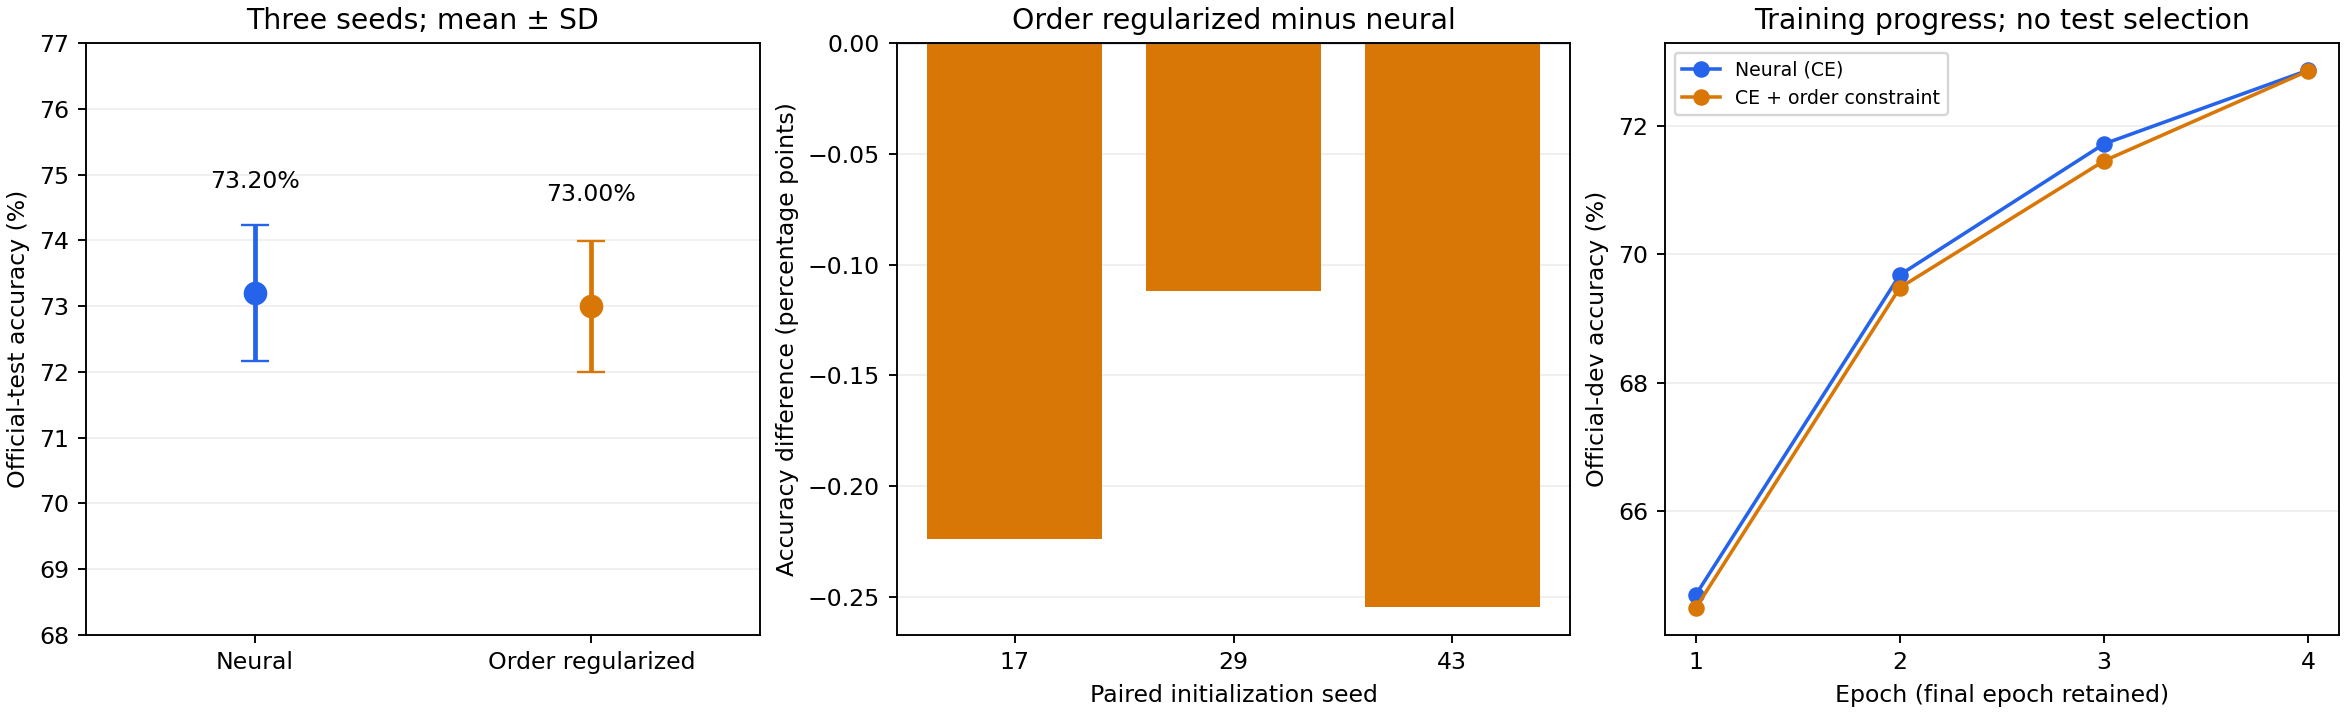

平均准确率差值（偏序组－神经组，百分点）： -0.1967969598262731


In [8]:
nli_rows = [{'method': r['arm'], 'seed': r['seed'],
             'test_accuracy_%': 100 * r['test']['accuracy'],
             'test_macro_F1_%': 100 * r['test']['macro_f1']}
            for r in nli_summary['results']]
display(pd.DataFrame(nli_rows).round(3))
display(Image(filename=str(nli_run / 'snli_comparison.png')))
print('平均准确率差值（偏序组－神经组，百分点）：',
      100 * nli_summary['order_minus_neural_accuracy_mean'])

In [9]:
from experiments.neurosymbolic_nli.inference import predict_pairs
nli_examples = [
    ('A dog is running .', 'An animal is running .'),
    ('A man is sleeping .', 'A man is awake .'),
    ('A person is standing .', 'A person is wearing a hat .'),
]
# 固定第一个种子展示，不按测试集挑选最好种子；以下是模型预测，不是形式证明。
nli_predictions = predict_pairs(nli_run, nli_examples, arm='neural', seed=17, device='cpu')
nli_probe_expected = ['entailment', 'contradiction', 'neutral']
for nli_prediction, nli_expected in zip(nli_predictions, nli_probe_expected):
    nli_prediction['expected_diagnostic_label'] = nli_expected
    nli_prediction['matches_expectation'] = nli_prediction['prediction'] == nli_expected
display(pd.DataFrame(nli_predictions))

,premise,hypothesis,prediction,probabilities,forward_order_energy,reverse_order_energy,arm,seed,expected_diagnostic_label,matches_expectation
0,A dog is running .,An animal is running .,entailment,"{'entailment': 0.9901987314224243, 'contradict...",0.000269,0.015908,neural,17,entailment,True
1,A man is sleeping .,A man is awake .,entailment,"{'entailment': 0.8548814654350281, 'contradict...",0.006125,0.040676,neural,17,contradiction,False
2,A person is standing .,A person is wearing a hat .,entailment,"{'entailment': 0.8612257838249207, 'contradict...",0.000601,0.008392,neural,17,neutral,False


In [10]:
import sys
nli_reproduce_command = [sys.executable,
    str(nli_project / 'experiments/neurosymbolic_nli/run_experiment.py'),
    '--run-dir', str(nli_run)]
print('复现命令：', nli_reproduce_command)
print('完整说明：', nli_run / 'REPORT.md')
print('核查通过项目：', sum(nli_verification['checks'].values()))

复现命令： ['/home/lgd/anaconda3/bin/python', '/mnt/c/Users/lgd/PycharmProjects/JupyterProject1/experiments/neurosymbolic_nli/run_experiment.py', '--run-dir', '/mnt/c/Users/lgd/PycharmProjects/JupyterProject1/runs/neurosymbolic_nli/20260915_order_v1']
完整说明： /mnt/c/Users/lgd/PycharmProjects/JupyterProject1/runs/neurosymbolic_nli/20260915_order_v1/REPORT.md
核查通过项目： 24


本轮偏序正则的平均测试准确率为 73.001%，神经对照为 73.198%，差值 -0.197 个百分点。三个种子均下降，因此本轮不支持“偏序正则提高 SNLI 准确率”的结论。

本轮采用普通神经对照作为默认分类模型，保留偏序模型与离散闭包用于进一步研究。18 项结构核查通过，六次测试预测均独立重算通过；这些结果证明实现与验证可复现，不能证明逻辑约束一定提高自然语言准确率。

原四句示例只留出一条关系边，并未留出句子；“吠叫”与“跑步”也不是逻辑矛盾。严格结构性质、近似阈值行为和真实文本泛化必须分开报告。

诊断样例中仍有明显错误（如 sleeping→awake 被预测为蕴涵），说明模型仍可能依赖词面重叠。这里完整展示失败，模型输出不能视为形式逻辑证明。

依据：[序嵌入原论文](https://arxiv.org/abs/1511.06361)、[SNLI 官方数据说明](https://nlp.stanford.edu/projects/snli/)。